In [ ]:
%pip install numpy pandas scipy sdv matplotlib gensim scikit-learn

In [4]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.decomposition import PCA

In [5]:
from gensim.models.fasttext import FastText
from gensim.test.utils import datapath

VECTOR_SIZE = 300

corpus_file = datapath('lee_background.cor')

model = FastText(vector_size=VECTOR_SIZE)
model.build_vocab(corpus_file=corpus_file)
model.train(
    corpus_file=corpus_file, epochs=model.epochs,
    total_examples=model.corpus_count, total_words=model.corpus_total_words,
)

with open("../fasttext_lee_background", "w+") as file:
    model.save(file.name)

In [6]:
df = pd.read_csv('../test.csv')
df.head()

,id,article,highlights
0,92c514c913c0bdfe25341af9fd72b29db544099b,Ever noticed how plane seats appear to be gett...,Experts question if packed out planes are put...
1,2003841c7dc0e7c5b1a248f9cd536d727f27a45a,A drunk teenage boy had to be rescued by secur...,Drunk teenage boy climbed into lion enclosure ...
2,91b7d2311527f5c2b63a65ca98d21d9c92485149,Dougie Freedman is on the verge of agreeing a ...,Nottingham Forest are close to extending Dougi...
3,caabf9cbdf96eb1410295a673e953d304391bfbb,Liverpool target Neto is also wanted by PSG an...,Fiorentina goalkeeper Neto has been linked wit...
4,3da746a7d9afcaa659088c8366ef6347fe6b53ea,Bruce Jenner will break his silence in a two-h...,"Tell-all interview with the reality TV star, 6..."


In [7]:
df = df.iloc[:, 1:]
df.dropna()
df

,article,highlights
0,Ever noticed how plane seats appear to be gett...,Experts question if packed out planes are put...
1,A drunk teenage boy had to be rescued by secur...,Drunk teenage boy climbed into lion enclosure ...
2,Dougie Freedman is on the verge of agreeing a ...,Nottingham Forest are close to extending Dougi...
3,Liverpool target Neto is also wanted by PSG an...,Fiorentina goalkeeper Neto has been linked wit...
4,Bruce Jenner will break his silence in a two-h...,"Tell-all interview with the reality TV star, 6..."
...,...,...
11485,Our young Earth may have collided with a body ...,Oxford scientists say a Mercury-like body stru...
11486,A man facing trial for helping his former love...,Man accused of helping former lover kill woman...
11487,A dozen or more metal implements are arranged ...,Marianne Power tried the tuning fork facial at...
11488,Brook Lopez dominated twin brother Robin with ...,Brooklyn Nets beat the Portland Trail Blazers ...


In [8]:
from gensim.models import Word2Vec, FastText
from gensim.utils import simple_preprocess

model = FastText.load("../fasttext_lee_background")

MAX_TOKENS_PER_ENTRY = 32

def get_vectorised_entries(entries):
    features = []
    for entry in entries:
        tokens = simple_preprocess(entry, min_len=1)
        vectors = [model.wv[token] for token in tokens]
        features.append(np.mean(vectors, axis=0))
    return np.array(features)

def vectorise_entries(entries):
    features = []
    for entry in entries:
        tokens = simple_preprocess(entry)
        vectors = [model.wv[token] for token in tokens]
        length = min(len(vectors), MAX_TOKENS_PER_ENTRY)
        trimmed_vectors = vectors[:length]
        if length < MAX_TOKENS_PER_ENTRY:
            padding_vectors = [np.zeros(VECTOR_SIZE) for _ in range(MAX_TOKENS_PER_ENTRY - length)]
            trimmed_vectors += padding_vectors
        features.append(np.concatenate(trimmed_vectors))
    return np.array(features)

In [9]:
summary_stats = []
features_data = []

df_sample = df.sample(10000)

for column in df_sample.columns:
    entries = [x for x in df_sample[column]]
    features = get_vectorised_entries(entries)

    vectorised_entries = vectorise_entries(entries)
    mean = np.mean(vectorised_entries, axis=0)
    standard_deviation = np.std(vectorised_entries, axis=0)
    median = np.median(vectorised_entries, axis=0)
    asymmetry = stats.skew(vectorised_entries, axis=0)
    excess = stats.kurtosis(vectorised_entries, axis=0)

    cov_matrix = np.cov(vectorised_entries.T)
    mean_vector = np.mean(vectorised_entries, axis=0)
    vector_dim = vectorised_entries.shape[1]

    summary_stats.append({
        'column': column,
        'overall_mean': np.mean(mean),
        'overall_std': np.mean(standard_deviation),
        'std_of_means': np.std(mean),
        'mean_of_medians': np.mean(median),
        'asymmetry_avg': np.mean(asymmetry),
        'excess_avg': np.mean(excess),
        'n_entries': len(entries),
        'vector_dim': vectorised_entries.shape[1],
        'mean_vector': mean_vector,
        'cov_matrix': cov_matrix,
        'cov_diagonal': np.diag(cov_matrix),
        'cov_trace': np.trace(cov_matrix),
        'cov_det': np.linalg.det(cov_matrix + np.eye(vectorised_entries.shape[1]) * 1e-6)  # определитель (с регуляризацией)
    })

    features_data.append({
        'column': column,
        'features': features,
        'vectorised': vectorised_entries
})

summary_df = pd.DataFrame(summary_stats)
summary_df

,column,overall_mean,overall_std,std_of_means,mean_of_medians,asymmetry_avg,excess_avg,n_entries,vector_dim,mean_vector,cov_matrix,cov_diagonal,cov_trace,cov_det
0,article,-0.015631,0.087525,0.200329,-0.014683,-0.031923,-0.268024,10000,9600,"[-0.0014229687, 0.10562723, -0.15537891, 0.079...","[[2.6710019241599953e-06, -9.745588688977651e-...","[2.6710019241599953e-06, 0.005665761307308618,...",117.09223,0.0
1,highlights,-0.014843,0.090349,0.190707,-0.013699,-0.036467,-0.146716,10000,9600,"[-0.001399469608174263, 0.08298960115921636, -...","[[1.4084784635593825e-06, -5.9793448304094756e...","[1.4084784635593825e-06, 0.0038691442297047384...",125.19218,0.0


In [10]:
def generate_synthetic_vectors(summary_df, method):
    synthetic_data = []
    for i, row in summary_df.iterrows():
        print(f"{i}: {row['column']}")
        n_samples = row['n_entries']
        vector_dim = row['vector_dim']
        if method == 'normal':
            mean_vec = np.full(vector_dim, row['overall_mean'])
            cov_matrix = np.eye(vector_dim) * (row['std_of_means'] ** 2)
            synthetic_vectors = stats.multivariate_normal.rvs(
                mean=mean_vec,
                cov=cov_matrix,
                size=n_samples
            )
        elif method == 'statistical_adjustment':
            base_vectors = np.random.normal(
                loc=row['overall_mean'],
                scale=row['overall_std'],
                size=(n_samples, vector_dim)
            )
            synthetic_vectors = adjust_statistics(
                base_vectors,
                target_mean=row['overall_mean'],
                target_std=row['overall_std']
            )
        elif method == 'covariance_based':
            mean_vector = row['mean_vector']
            cov_matrix = row['cov_matrix']
            cov_matrix = cov_matrix + np.eye(vector_dim) * 1e-6
            synthetic_vectors = stats.multivariate_normal.rvs(
                mean=mean_vector, cov=cov_matrix, size=n_samples
            )
    entries = []
    for vector in synthetic_vectors:
        entry = ""
        for i in range(MAX_TOKENS_PER_ENTRY):
            vectorised_token = vector[i * VECTOR_SIZE:(i + 1) * VECTOR_SIZE]
            most_similar_words = model.wv.similar_by_vector(vectorised_token, topn=5)
            for word, _ in most_similar_words:
                if str(word).isalnum():
                    entry += f" {word[0]}"
        entries.append(entry.strip())
    synthetic_data.append({
        'column': row['column'],
        'vectors': synthetic_vectors,
        'entries': entries,
        'original_stats': row
    })

    return synthetic_data

def adjust_statistics(vectors, target_mean, target_std):
    vectors = vectors - np.mean(vectors, axis=0)
    current_std = np.std(vectors, axis=0) + 1e-8
    vectors = vectors * (target_std / current_std)
    vectors = vectors + target_mean
    return vectors

In [11]:
def validate_synthetic_data(synthetic_data):
    validation_results = []
    
    for data in synthetic_data:
        original_stats = data['original_stats']
        synthetic_vectors = np.asarray(data['vectors'])

        synth_mean = np.mean(synthetic_vectors, axis=0)
        synth_std = np.std(synthetic_vectors, axis=0)
        synth_skew = stats.skew(synthetic_vectors, axis=0)
        synth_kurt = stats.kurtosis(synthetic_vectors, axis=0)
        synth_mean_avg = np.mean(synth_mean)
        synth_std_avg = np.mean(synth_std)
        synth_skew_avg = np.mean(synth_skew)
        synth_kurt_avg = np.mean(synth_kurt)
        
        validation_results.append({
            'column': original_stats['column'],
            'mean_error': abs(synth_mean_avg - original_stats['overall_mean']),
            'std_error': abs(synth_std_avg - original_stats['overall_std']),
            'skew_error': abs(synth_skew_avg - original_stats['asymmetry_avg']),
            'kurt_error': abs(synth_kurt_avg - original_stats['excess_avg']),
            'original_mean': original_stats['overall_mean'],
            'original_std': original_stats['overall_std'],
            'original_skew': original_stats['asymmetry_avg'],
            'original_kurt': original_stats['excess_avg'],
            'synthetic_mean': synth_mean_avg,
            'synthetic_std': synth_std_avg,
            'synthetic_skew': synth_skew_avg,
            'synthetic_kurt': synth_kurt_avg,
            'n_samples': len(synthetic_vectors),
            'vector_dim': original_stats['vector_dim']
        })
    
    return pd.DataFrame(validation_results)


def visualize_distributions(synthetic_data, features_data, column_name=None, n_dimensions=5, use_pca=True):
    if column_name:
        synthetic_item = next((item for item in synthetic_data if item['column'] == column_name), None)
        original_item = next((item for item in features_data if item['column'] == column_name), None)
    else:
        synthetic_item = synthetic_data[0] if synthetic_data else None
        original_item = features_data[0] if features_data else None

    original_vectors = np.asarray(original_item['vectorised'])
    synthetic_vectors = np.asarray(synthetic_item['vectors'])
    col_name = synthetic_item['column']
    print(f"{col_name}")
    print(f"Исходные: {original_vectors.shape}, Синтетические: {synthetic_vectors.shape}")
    dim_indices = np.linspace(0, original_vectors.shape[1] - 1, n_dimensions, dtype=int)

    fig, axes = plt.subplots(2, n_dimensions, figsize=(4*n_dimensions, 8))
    fig.suptitle(f'Распределения по измерениям: {col_name}', fontsize=14, fontweight='bold')
    for i, dim_idx in enumerate(dim_indices):
        axes[0, i].hist(original_vectors[:, dim_idx], bins=50, alpha=0.7, color='blue', 
                       label='Исходные', density=True)
        axes[0, i].set_title(f'Измерение {dim_idx}')
        axes[0, i].set_xlabel('Значение')
        axes[0, i].set_ylabel('Плотность')
        axes[0, i].legend()
        axes[0, i].grid(True, alpha=0.3)

        axes[1, i].hist(synthetic_vectors[:, dim_idx], bins=50, alpha=0.7, color='red', 
                       label='Синтетические', density=True)
        axes[1, i].set_title(f'Измерение {dim_idx}')
        axes[1, i].set_xlabel('Значение')
        axes[1, i].set_ylabel('Плотность')
        axes[1, i].legend()
        axes[1, i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    n_compare = min(3, n_dimensions)
    fig, axes = plt.subplots(1, n_compare, figsize=(5*n_compare, 4))
    if n_compare == 1:
        axes = [axes]
    fig.suptitle(f'Сравнение распределений: {col_name}', fontsize=14, fontweight='bold')
    
    for i, dim_idx in enumerate(dim_indices[:n_compare]):
        axes[i].hist(original_vectors[:, dim_idx], bins=50, alpha=0.6, color='blue', 
                    label='Исходные', density=True)
        axes[i].hist(synthetic_vectors[:, dim_idx], bins=50, alpha=0.6, color='red', 
                    label='Синтетические', density=True)
        axes[i].set_title(f'Измерение {dim_idx}')
        axes[i].set_xlabel('Значение')
        axes[i].set_ylabel('Плотность')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    orig_mean = np.mean(original_vectors, axis=0)
    orig_std = np.std(original_vectors, axis=0)
    orig_skew = stats.skew(original_vectors, axis=0)
    orig_kurt = stats.kurtosis(original_vectors, axis=0)
    synth_mean = np.mean(synthetic_vectors, axis=0)
    synth_std = np.std(synthetic_vectors, axis=0)
    synth_skew = stats.skew(synthetic_vectors, axis=0)
    synth_kurt = stats.kurtosis(synthetic_vectors, axis=0)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Распределение статистик по измерениям: {col_name}', 
                 fontsize=14, fontweight='bold')
    
    stats_data = [
        (orig_mean, synth_mean, 'Среднее'),
        (orig_std, synth_std, 'Стандартное отклонение'),
        (orig_skew, synth_skew, 'Асимметрия'),
        (orig_kurt, synth_kurt, 'Эксцесс')
    ]
    
    for idx, (orig_stat, synth_stat, label) in enumerate(stats_data):
        ax = axes[idx // 2, idx % 2]
        ax.hist(orig_stat, bins=50, alpha=0.6, color='blue', 
               label='Исходные', density=True)
        ax.hist(synth_stat, bins=50, alpha=0.6, color='red', 
               label='Синтетические', density=True)
        ax.set_title(label)
        ax.set_xlabel('Значение')
        ax.set_ylabel('Плотность')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    if use_pca and original_vectors.shape[1] > 2:
        from sklearn.decomposition import PCA
        combined = np.vstack([original_vectors, synthetic_vectors])
        pca = PCA(n_components=2)
        pca.fit(combined)
        orig_2d = pca.transform(original_vectors)
        synth_2d = pca.transform(synthetic_vectors)
        fig, ax = plt.subplots(1, 1, figsize=(10, 8))
        ax.scatter(orig_2d[:, 0], orig_2d[:, 1], alpha=0.5, s=10, 
                  c='blue', label='Исходные', marker='o')
        ax.scatter(synth_2d[:, 0], synth_2d[:, 1], alpha=0.5, s=10, 
                  c='red', label='Синтетические', marker='^')
        ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
        ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
        ax.set_title(f'2D проекция через PCA: {col_name}')
        ax.legend()
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    orig_sorted = np.sort(orig_mean)
    synth_sorted = np.sort(synth_mean)
    n = len(orig_sorted)
    quantiles = np.linspace(0, 1, min(n, 1000))
    orig_quantiles = np.quantile(orig_sorted, quantiles)
    synth_quantiles = np.quantile(synth_sorted, quantiles)
    
    ax.scatter(orig_quantiles, synth_quantiles, alpha=0.6, s=20)

    min_val = min(orig_quantiles.min(), synth_quantiles.min())
    max_val = max(orig_quantiles.max(), synth_quantiles.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Идеал')
    
    ax.set_xlabel('Квантили исходных')
    ax.set_ylabel('Квантили синтетических')
    ax.set_title(f'Q-Q Plot: {col_name}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

Обработка колонки 0: article
Обработка колонки 1: highlights
       column  mean_error     std_error  skew_error  kurt_error
0  highlights         0.0  9.999585e-09    0.036599    0.145873
highlights
Исходные: (10000, 9600), Синтетические: (10000, 9600)


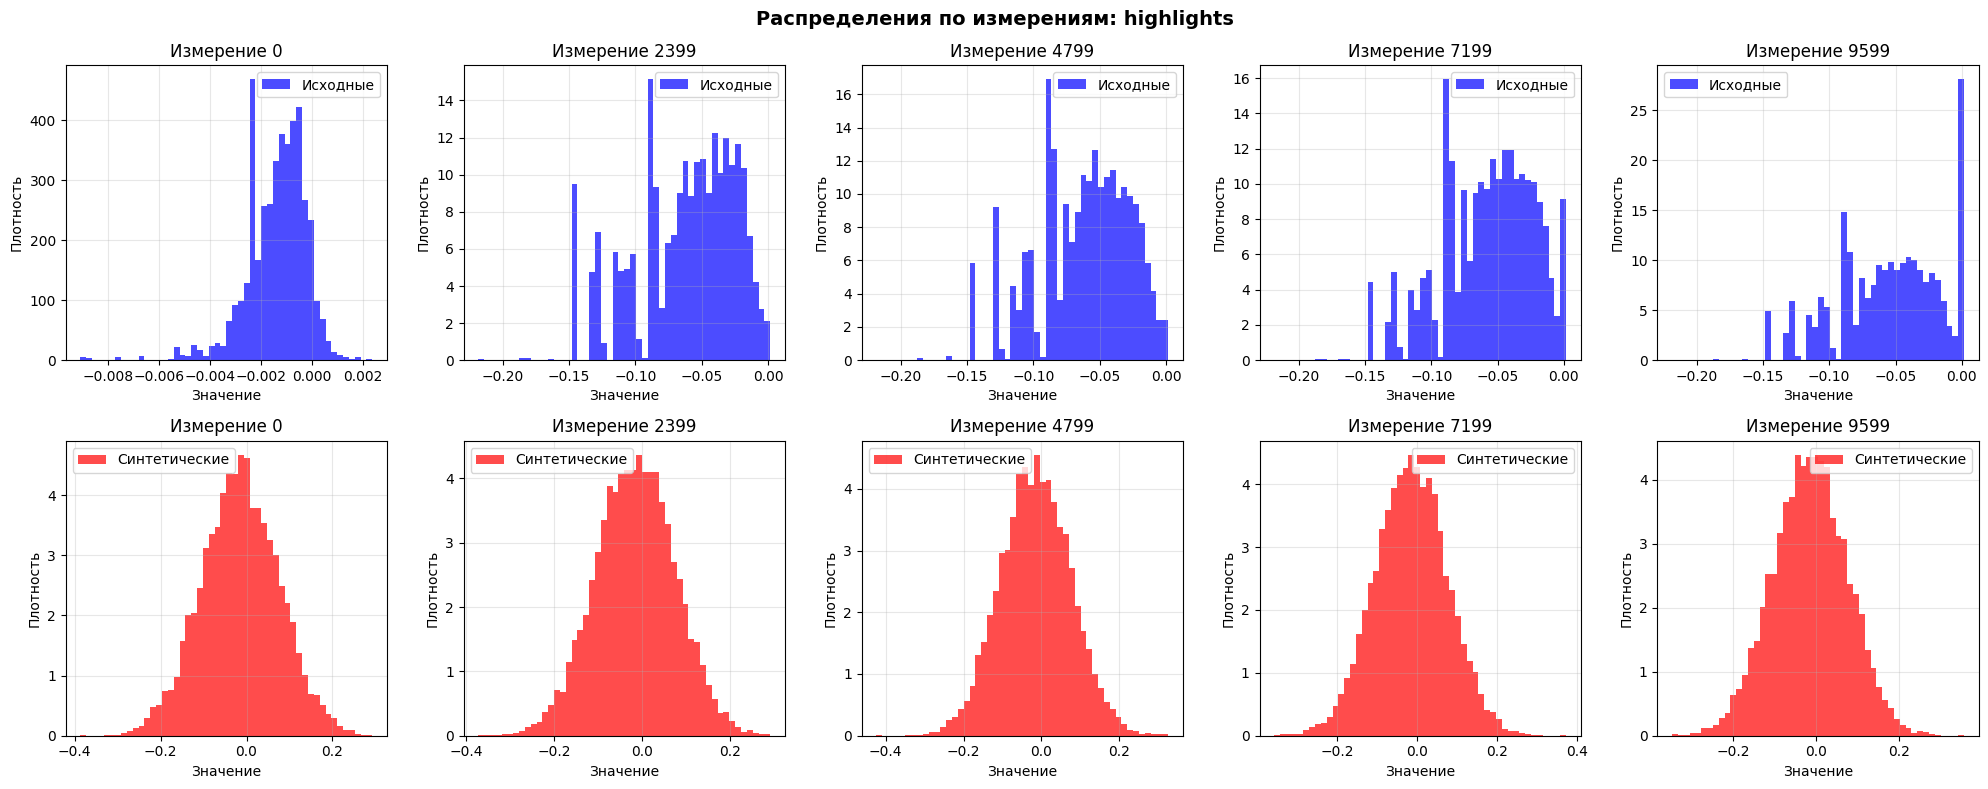

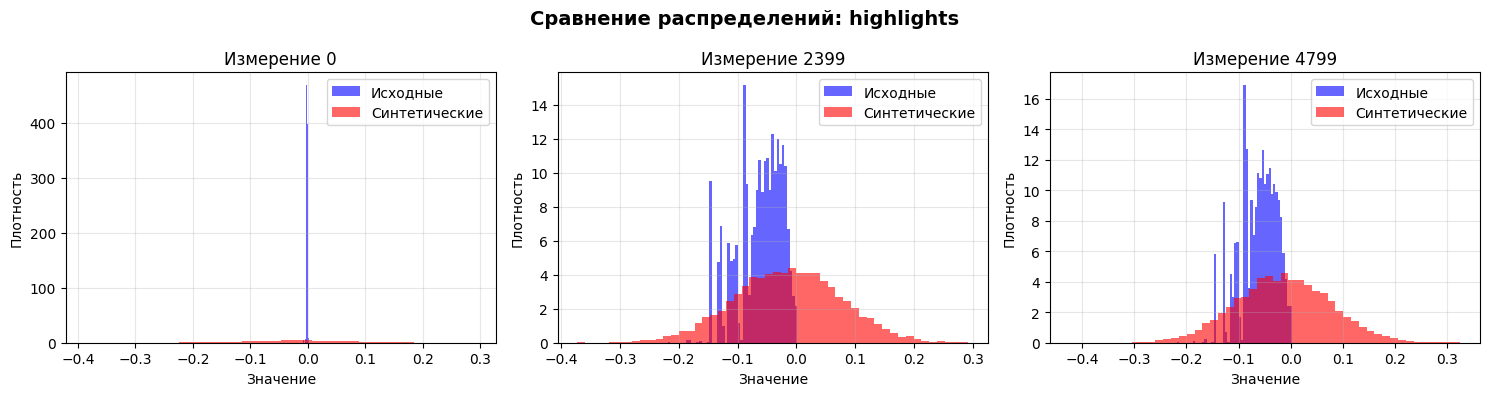

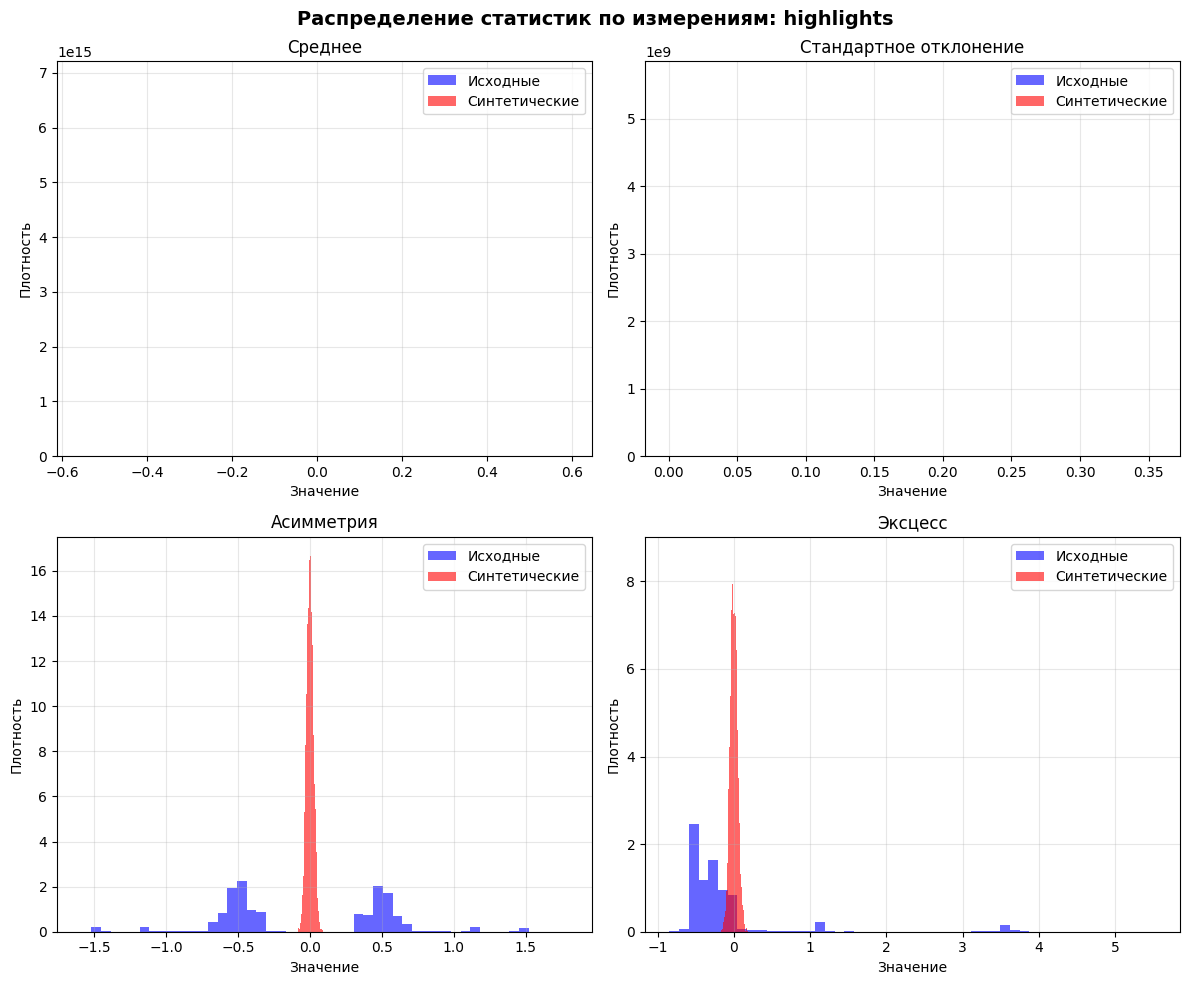

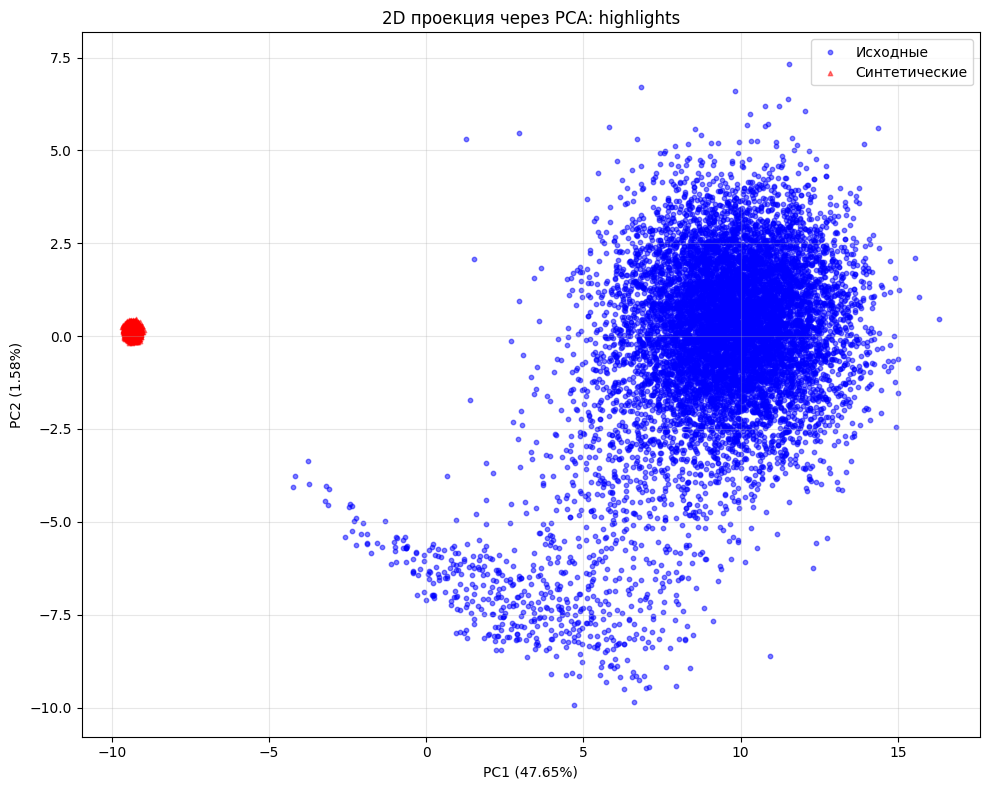

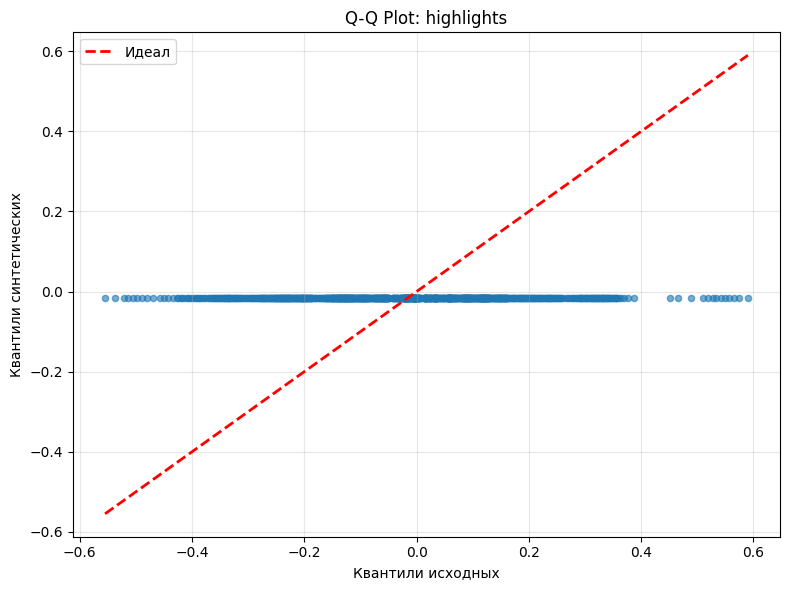

In [12]:
method = 'statistical_adjustment'

try:
    synthetic_data_sa = generate_synthetic_vectors(summary_df, method=method)
    validation_df_sa = validate_synthetic_data(synthetic_data_sa)
    print(validation_df_sa[['column', 'mean_error', 'std_error', 'skew_error', 'kurt_error']])
    visualize_distributions(synthetic_data_sa, features_data, 
                           column_name=synthetic_data_sa[0]['column'])
    
except Exception as e:
    print(f"{e}")
    import traceback
    traceback.print_exc()

In [ ]:
method = 'covariance_based'

try:
    synthetic_data_cov = generate_synthetic_vectors(summary_df, method=method)
    validation_df_cov = validate_synthetic_data(synthetic_data_cov)
    print(validation_df_cov[['column', 'mean_error', 'std_error', 'skew_error', 'kurt_error']])
    visualize_distributions(synthetic_data_cov, features_data, 
                           column_name=synthetic_data_cov[0]['column'])
    
except Exception as e:
    print(f"{e}")
    import traceback
    traceback.print_exc()

Обработка колонки 0: article
